# Arsalan Ibrahim | CRH-2026-AI-034 | Code Room Hub | Week 1

# Week 1 - Benchmarking Six Open Models Locally (RTX 3050, 8 GB)

Notebook 1 built the decoder block by hand. This one measures the real models.

**Hardware:** RTX 3050 8 GB, run locally rather than on Colab. Two reasons for local: nothing
disconnects mid-run, and the downloaded weights stay cached so a second pass costs nothing.

Ampere also gives two things Colab's T4 could not: bf16 support and a working FlashAttention 2
path. The tradeoff is capacity, 8 GB against the T4's 16 GB, which only matters for the Mistral
entry.

## Why every model is loaded in 4-bit

Size-matching all six is impossible. Mistral's smallest open-weight release is 7B and the
smallest Phi instruct model is 3.8B, while Llama, Qwen, Gemma and DeepSeek all publish
something in the 1-2B range.

So precision is held constant instead of size: **every model runs in 4-bit NF4 via
BitsAndBytes.** One variable fixed, a 7B model fits in 8 GB, and the quantization requirement
is covered in the same pass. The cost is that size becomes the uncontrolled variable, so a
slower model may simply be a bigger model. Parameter count stays in the results table so that
remains visible.

Section 8 isolates quantization properly by running one model at both bf16 and 4-bit.

## Two things to flag about the model list

- **DeepSeek-R1-Distill-Qwen-1.5B is a Qwen2 architecture** distilled from R1, not an original
  DeepSeek design. Counting it as an independent sixth family would be wrong.
- **Llama and Gemma are gated.** Accept the licence on each model page with the account whose
  token you use here. Mistral, Qwen, DeepSeek and Phi need no permission.

## 0. Setup

Run these in a terminal, not in the notebook. Create the environment first so the CUDA build of
PyTorch is the one that gets installed.

**Linux / WSL2**

```bash
python -m venv .venv
source .venv/bin/activate
pip install torch --index-url https://download.pytorch.org/whl/cu124
pip install transformers accelerate bitsandbytes jupyter ipywidgets pandas matplotlib
huggingface-cli login
```

**Windows (native)**

Same commands, but activate with `.venv\Scripts\activate`. BitsAndBytes ships Windows wheels
now, but they break more often than the Linux path. If `import bitsandbytes` fails or reports
no CUDA, move to WSL2 rather than fighting it.

**Before launching Jupyter**, set the allocator flag. This reduces fragmentation, which is the
usual cause of an out-of-memory error on the last model of a sequential loop rather than the
first.

```bash
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True   # Windows: set PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
jupyter notebook
```

**Disk:** the full-precision weights are downloaded before BitsAndBytes quantizes them in
memory, so budget about 25 GB. Mistral alone is roughly 14 GB.

**Close anything else using the GPU** before running. On a display GPU the desktop already
costs you 0.5-1 GB, and browsers with hardware acceleration cost more.

In [1]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [2]:
import gc
import json
import os
import platform
import time
from dataclasses import dataclass, asdict, field
from pathlib import Path

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

assert torch.cuda.is_available(), "No CUDA device found. Check the torch install is the CUDA build."

DEVICE = "cuda:0"
props = torch.cuda.get_device_properties(0)
TOTAL_VRAM_GB = props.total_memory / 1e9

# Ampere and later support bf16, which has the same exponent range as fp32 and so is
# less prone to overflow than fp16 during dequantization.
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

OUTDIR = Path("results")
OUTDIR.mkdir(exist_ok=True)
RESULTS_PATH = OUTDIR / "benchmark_results.json"

print("os:            ", platform.system(), platform.release())
print("gpu:           ", props.name)
print("vram:           %.1f GB" % TOTAL_VRAM_GB)
print("compute dtype: ", COMPUTE_DTYPE)
print("alloc config:  ", os.environ.get("PYTORCH_CUDA_ALLOC_CONF", "(not set)"))
print("results ->     ", RESULTS_PATH.resolve())

if os.environ.get("PYTORCH_CUDA_ALLOC_CONF") != "expandable_segments:True":
    print("\nWARNING: PYTORCH_CUDA_ALLOC_CONF is not set. Restart Jupyter with it exported.")

os:             Windows 11
gpu:            NVIDIA GeForce RTX 3050
vram:           8.6 GB
compute dtype:  torch.bfloat16
alloc config:   (not set)
results ->      C:\Users\Ibrahim\llm-week1\results\benchmark_results.json



## 1. The models

One entry per family, each family's smallest instruct-tuned release. Mistral is deliberately
last: it is the only model that stresses 8 GB, so by the time it loads everything else is
already benchmarked and saved.

In [3]:
MODELS = {
    "Llama-3.2-1B": {
        "repo": "meta-llama/Llama-3.2-1B-Instruct",
        "params_b": 1.24,
        "gated": True,
        "note": "",
    },
    "Qwen2.5-1.5B": {
        "repo": "Qwen/Qwen2.5-1.5B-Instruct",
        "params_b": 1.54,
        "gated": False,
        "note": "",
    },
    "Gemma-2-2B": {
        "repo": "google/gemma-2-2b-it",
        "params_b": 2.61,
        "gated": True,
        "note": "sliding window attention on alternate layers",
    },
    "DeepSeek-R1-Distill-1.5B": {
        "repo": "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
        "params_b": 1.78,
        "gated": False,
        "note": "Qwen2 architecture distilled from R1, not an original DeepSeek design",
    },
    "Phi-3.5-mini": {
        "repo": "microsoft/Phi-3.5-mini-instruct",
        "params_b": 3.82,
        "gated": False,
        "note": "smallest Phi instruct model, no ~1B option exists",
    },
    "Mistral-7B-v0.3": {
        "repo": "mistralai/Mistral-7B-Instruct-v0.3",
        "params_b": 7.25,
        "gated": False,
        "note": "smallest Mistral open weights, roughly 6x the Llama entry",
    },
}

for name, m in MODELS.items():
    print("%-26s %-45s %5.2fB %s" % (name, m["repo"], m["params_b"],
                                     "(gated)" if m["gated"] else ""))

Llama-3.2-1B               meta-llama/Llama-3.2-1B-Instruct               1.24B (gated)
Qwen2.5-1.5B               Qwen/Qwen2.5-1.5B-Instruct                     1.54B 
Gemma-2-2B                 google/gemma-2-2b-it                           2.61B (gated)
DeepSeek-R1-Distill-1.5B   deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B      1.78B 
Phi-3.5-mini               microsoft/Phi-3.5-mini-instruct                3.82B 
Mistral-7B-v0.3            mistralai/Mistral-7B-Instruct-v0.3             7.25B 


### Preflight: check access before downloading anything

`auth_check` verifies the token against each repo without pulling weights. Two seconds here
saves discovering a permissions problem twenty minutes into a download.

In [4]:
from huggingface_hub import auth_check
from huggingface_hub.utils import GatedRepoError, RepositoryNotFoundError

blocked = []
for name, spec in MODELS.items():
    try:
        auth_check(spec["repo"])
        print("OK       %s" % name)
    except GatedRepoError:
        print("PENDING  %s  <- licence not granted yet" % name)
        blocked.append(name)
    except RepositoryNotFoundError:
        print("MISSING  %s  <- check the repo id, or you are not logged in" % name)
        blocked.append(name)
    except Exception as e:
        print("ERROR    %s  %s" % (name, type(e).__name__))
        blocked.append(name)

if blocked:
    print("\nSkipping for now:", ", ".join(blocked))
    print("Re-run the benchmark loop once they are granted. It skips whatever is already saved.")

OK       Llama-3.2-1B
OK       Qwen2.5-1.5B
OK       Gemma-2-2B
OK       DeepSeek-R1-Distill-1.5B
OK       Phi-3.5-mini
OK       Mistral-7B-v0.3


## 2. Tokenization

Tokenizers are worth comparing before the models are loaded, because they cost nothing to
download and they change the economics of everything downstream.

The six do not agree on vocabulary size, and the spread is large. A bigger vocabulary means
fewer tokens for the same sentence, which means fewer forward passes to say the same thing, and
therefore lower real cost per sentence even if tokens-per-second looks identical. It also means
a larger embedding matrix, which on a small model is a serious share of total parameters.

The other thing this exposes: context windows are quoted in tokens, so two models with the same
advertised context do not hold the same amount of actual text.

In [5]:
SAMPLE = (
    "The transformer architecture replaced recurrence with attention in 2017. "
    "Since then, decoder-only models have become the standard for text generation, "
    "and inference cost is dominated by the KV cache rather than the weights."
)

CODE_SAMPLE = "def reverse(head):\n    prev = None\n    while head:\n        head = head.next\n"

URDU_SAMPLE = "\u0645\u0634\u06cc\u0646 \u0644\u0631\u0646\u0646\u06af \u0627\u06cc\u06a9 \u062f\u0644\u0686\u0633\u067e \u0645\u0648\u0636\u0648\u0639 \u06c1\u06d2\u06d4"

tok_rows = []
for name, spec in MODELS.items():
    if name in blocked:
        continue
    try:
        tok = AutoTokenizer.from_pretrained(spec["repo"])
        n_en = len(tok.encode(SAMPLE, add_special_tokens=False))
        n_code = len(tok.encode(CODE_SAMPLE, add_special_tokens=False))
        n_ur = len(tok.encode(URDU_SAMPLE, add_special_tokens=False))
        tok_rows.append({
            "model": name,
            "vocab": len(tok),
            "english": n_en,
            "chars/token": round(len(SAMPLE) / n_en, 2),
            "code": n_code,
            "urdu": n_ur,
        })
    except Exception as e:
        print("tokenizer failed for %s: %s" % (name, type(e).__name__))

import pandas as pd
tok_df = pd.DataFrame(tok_rows).sort_values("vocab", ascending=False)
tok_df

[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


,model,vocab,english,chars/token,code,urdu
2,Gemma-2-2B,256000,43,5.19,23,11
1,Qwen2.5-1.5B,151665,42,5.31,19,19
3,DeepSeek-R1-Distill-1.5B,151665,42,5.31,19,19
0,Llama-3.2-1B,128256,40,5.58,19,19
5,Mistral-7B-v0.3,32768,48,4.65,23,30
4,Phi-3.5-mini,32011,48,4.65,23,32


In [6]:
# what the same sentence actually splits into, first 20 pieces
for name, spec in list(MODELS.items())[:3]:
    if name in blocked:
        continue
    tok = AutoTokenizer.from_pretrained(spec["repo"])
    pieces = tok.tokenize("The KV cache makes generation cheaper.")
    print("%-26s %d tokens" % (name, len(pieces)))
    print("   ", pieces)

Llama-3.2-1B               7 tokens
    ['The', 'ĠKV', 'Ġcache', 'Ġmakes', 'Ġgeneration', 'Ġcheaper', '.']
Qwen2.5-1.5B               7 tokens
    ['The', 'ĠKV', 'Ġcache', 'Ġmakes', 'Ġgeneration', 'Ġcheaper', '.']
Gemma-2-2B                 7 tokens
    ['The', '▁KV', '▁cache', '▁makes', '▁generation', '▁cheaper', '.']


## 3. Loading with BitsAndBytes

`load_in_4bit` with the NF4 data type. Double quantization compresses the quantization
constants themselves, saving roughly another 0.4 bits per parameter. Compute dtype is bf16 here
because the 3050 is Ampere; on Turing this would have to be fp16.

Weights are stored in 4 bits but each block is dequantized back to bf16 for the actual matmul,
so this trades a little speed for a large memory saving.

The VRAM guard exists because an 8 GB card running a display has less free memory than it
advertises. It estimates before loading rather than discovering the problem partway through.

In [7]:
BNB_4BIT = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)


def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


def free_vram_gb():
    free_bytes, _ = torch.cuda.mem_get_info()
    return free_bytes / 1e9


def vram_guard(params_b, quantized=True, headroom_gb=1.5):
    """Rough check before loading. 4-bit costs about 0.6 GB per billion parameters
    including quantization constants; bf16 costs about 2.0."""
    per_b = 0.6 if quantized else 2.0
    need = params_b * per_b + headroom_gb
    have = free_vram_gb()
    print("estimated need %.1f GB | free %.1f GB" % (need, have))
    if need > have:
        print("WARNING: this is likely to OOM. Close other GPU applications and restart the kernel.")
    return need <= have


def load_model(repo, quant_config=BNB_4BIT, dtype=None):
    """Returns (model, tokenizer, load_seconds, weight_memory_gb)."""
    free_gpu()
    before = torch.cuda.memory_allocated()
    t0 = time.perf_counter()

    tok = AutoTokenizer.from_pretrained(repo)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    kwargs = {
        "device_map": DEVICE,
        "low_cpu_mem_usage": True,
        "attn_implementation": "sdpa",
    }
    if quant_config is not None:
        kwargs["quantization_config"] = quant_config
    else:
        kwargs["torch_dtype"] = dtype or COMPUTE_DTYPE

    model = AutoModelForCausalLM.from_pretrained(repo, **kwargs)
    model.eval()

    torch.cuda.synchronize()
    load_s = time.perf_counter() - t0
    weight_gb = (torch.cuda.memory_allocated() - before) / 1e9
    return model, tok, load_s, weight_gb


def unload(model, tok):
    del model, tok
    free_gpu()

## 4. What gets measured

Timing is split into two phases because they behave completely differently:

- **Prefill** processes the whole prompt in one parallel pass. Time to first token is
  essentially prefill time, and it is what a user perceives as lag before anything appears.
- **Decode** produces one token per forward pass, reusing the KV cache built by hand in
  notebook 1. This phase is memory-bandwidth bound rather than compute bound, and it sets the
  tokens per second seen while text streams.

A single "inference speed" number hides that distinction, so both are recorded.

Two things that keep the numbers honest:

- One warmup run per model, discarded. The first CUDA call pays kernel autotuning and allocator
  costs unrelated to the model.
- `torch.cuda.synchronize()` before reading the clock. CUDA calls are asynchronous, so without
  it the measurement is of how fast Python queues work, not how fast the GPU does it.

Peak memory comes from `max_memory_allocated`, reset before each run, capturing weights plus KV
cache plus activations at the high-water mark.

In [8]:
PROMPTS = [
    "Explain what a KV cache is and why it speeds up text generation.",
    "Write a Python function that reverses a linked list. Include a short comment.",
    "A shop sells pens at 12 rupees each. If I buy 7 and pay with a 100 rupee note, "
    "how much change do I get? Show your working.",
    "Summarise the difference between supervised and unsupervised learning in three sentences.",
    "What are two risks of deploying a large language model in a customer support product?",
]

MAX_NEW_TOKENS = 128
GPU_HOURLY_USD = 0.35   # rented-T4-equivalent placeholder, see section 9


@dataclass
class Result:
    model: str
    repo: str
    params_b: float
    precision: str
    gpu: str = ""
    load_seconds: float = 0.0
    weight_gb: float = 0.0
    peak_gb: float = 0.0
    ttft_ms: float = 0.0
    decode_tok_per_s: float = 0.0
    total_tok_per_s: float = 0.0
    context_window: int = 0
    vocab_size: int = 0
    n_layers: int = 0
    note: str = ""
    generations: list = field(default_factory=list)


@torch.no_grad()
def time_prefill(model, tok, prompt):
    """Time to first token, in ms."""
    ids = tok(prompt, return_tensors="pt").to(DEVICE)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    model(**ids)
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000


@torch.no_grad()
def time_generate(model, tok, prompt, max_new_tokens=MAX_NEW_TOKENS):
    """Returns (decoded_text, n_generated, total_seconds)."""
    ids = tok(prompt, return_tensors="pt").to(DEVICE)
    n_in = ids["input_ids"].shape[1]

    torch.cuda.synchronize()
    t0 = time.perf_counter()
    out = model.generate(
        **ids,
        max_new_tokens=max_new_tokens,
        do_sample=False,             # greedy, so runs are reproducible
        use_cache=True,
        pad_token_id=tok.pad_token_id,
    )
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    n_new = out.shape[1] - n_in
    text = tok.decode(out[0][n_in:], skip_special_tokens=True)
    return text, n_new, elapsed

In [9]:
def benchmark(name, spec, quant_config=BNB_4BIT, precision="4bit-nf4"):
    print("=" * 70)
    print(name, "|", precision)
    print("=" * 70)

    vram_guard(spec["params_b"], quantized=quant_config is not None)

    model, tok, load_s, weight_gb = load_model(spec["repo"], quant_config)
    cfg = model.config

    r = Result(
        model=name,
        repo=spec["repo"],
        params_b=spec["params_b"],
        precision=precision,
        gpu=props.name,
        load_seconds=round(load_s, 2),
        weight_gb=round(weight_gb, 3),
        context_window=getattr(cfg, "max_position_embeddings", 0),
        vocab_size=getattr(cfg, "vocab_size", 0),
        n_layers=getattr(cfg, "num_hidden_layers", 0),
        note=spec["note"],
    )

    time_generate(model, tok, "Hello.", max_new_tokens=8)   # warmup, discarded
    free_gpu()

    ttfts, tokens, seconds, decode_rates = [], [], [], []

    for p in PROMPTS:
        ttfts.append(time_prefill(model, tok, p))
        text, n_new, elapsed = time_generate(model, tok, p)

        tokens.append(n_new)
        seconds.append(elapsed)
        prefill_s = ttfts[-1] / 1000
        decode_s = max(elapsed - prefill_s, 1e-6)
        decode_rates.append((n_new - 1) / decode_s)

        r.generations.append({"prompt": p, "output": text.strip()})

    r.ttft_ms = round(sum(ttfts) / len(ttfts), 1)
    r.decode_tok_per_s = round(sum(decode_rates) / len(decode_rates), 1)
    r.total_tok_per_s = round(sum(tokens) / sum(seconds), 1)
    r.peak_gb = round(torch.cuda.max_memory_allocated() / 1e9, 3)

    print("load          %.2f s" % r.load_seconds)
    print("weights       %.2f GB" % r.weight_gb)
    print("peak vram     %.2f GB" % r.peak_gb)
    print("ttft          %.1f ms" % r.ttft_ms)
    print("decode        %.1f tok/s" % r.decode_tok_per_s)
    print("end to end    %.1f tok/s" % r.total_tok_per_s)
    print("context       {:,} tokens".format(r.context_window))

    unload(model, tok)
    return r

## 5. Run the benchmark

One model at a time, unloaded between each. Results are written after every model, so a crash
on model five keeps the four that finished and re-running the cell picks up where it stopped.

If Mistral OOMs, restart the kernel, re-run cells 0 through 4, then run this cell again. It
skips everything already saved.

In [10]:
results = []
quant_runs = []


def save_all():
    payload = {
        "gpu": props.name,
        "vram_gb": round(TOTAL_VRAM_GB, 1),
        "compute_dtype": str(COMPUTE_DTYPE),
        "max_new_tokens": MAX_NEW_TOKENS,
        "n_prompts": len(PROMPTS),
        "gpu_hourly_usd": GPU_HOURLY_USD,
        "sampling": "greedy",
        "tokenizers": tok_rows,
        "runs": [asdict(r) for r in results],
        "quantization_study": [asdict(r) for r in quant_runs],
    }
    with open(RESULTS_PATH, "w") as f:
        json.dump(payload, f, indent=2)


def load_previous():
    """Restore results from a previous session so a restart does not redo finished work."""
    if not RESULTS_PATH.exists():
        return
    with open(RESULTS_PATH) as f:
        prev = json.load(f)
    for d in prev.get("runs", []):
        results.append(Result(**d))
    print("restored %d previous runs" % len(results))


load_previous()

for name, spec in MODELS.items():
    if name in blocked:
        print("skipping (no access):", name)
        continue
    if any(r.model == name and r.precision == "4bit-nf4" for r in results):
        print("already done, skipping:", name)
        continue
    try:
        results.append(benchmark(name, spec))
        save_all()
        print("saved ->", RESULTS_PATH)
    except torch.cuda.OutOfMemoryError:
        print("OOM on %s. Restart the kernel and re-run this cell." % name)
        free_gpu()
    except Exception as e:
        print("FAILED %s: %s %s" % (name, type(e).__name__, str(e)[:200]))
        free_gpu()

print("\ncompleted %d of %d" % (len(results), len(MODELS)))

Llama-3.2-1B | 4bit-nf4
estimated need 2.2 GB | free 7.6 GB


W0805 21:29:10.328000 11168 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


load          10.99 s
weights       1.03 GB
peak vram     1.05 GB
ttft          50.9 ms
decode        37.4 tok/s
end to end    37.1 tok/s
context       131,072 tokens
saved -> results\benchmark_results.json
Qwen2.5-1.5B | 4bit-nf4
estimated need 2.4 GB | free 6.5 GB


...

load          13.17 s
weights       1.62 GB
peak vram     1.64 GB
ttft          50.2 ms
decode        23.7 tok/s
end to end    23.7 tok/s
context       131,072 tokens
saved -> results\benchmark_results.json
Phi-3.5-mini | 4bit-nf4
estimated need 3.8 GB | free 5.9 GB


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

load          25.57 s
weights       2.26 GB
peak vram     2.34 GB
ttft          61.8 ms
decode        29.4 tok/s
end to end    29.2 tok/s
context       131,072 tokens
saved -> results\benchmark_results.json
Mistral-7B-v0.3 | 4bit-nf4
estimated need 5.8 GB | free 5.1 GB


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

load          40.65 s
weights       4.15 GB
peak vram     4.19 GB
ttft          88.2 ms
decode        22.2 tok/s
end to end    22.1 tok/s
context       32,768 tokens
saved -> results\benchmark_results.json

completed 6 of 6


## 6. Quantization: bf16 against 4-bit

Section 5 holds precision constant, so it says nothing about what quantization itself costs.
This section takes one model and runs it both ways.

Qwen2.5-1.5B is the subject: ungated, and small enough that the bf16 version still fits in 8 GB
alongside its KV cache.

Expected outcome: memory down by roughly 3x, and decode speed **worse**, not better. 4-bit
weights must be dequantized before every matmul and that unpacking is extra work. Quantization
buys memory. It only buys speed when it is the thing that lets a model fit on the card at all
instead of spilling to system RAM.

In [11]:
QUANT_TARGET = "Qwen2.5-1.5B"
spec = MODELS[QUANT_TARGET]

quant_runs.clear()
for label, cfg_q in [("bf16", None), ("4bit-nf4", BNB_4BIT)]:
    try:
        quant_runs.append(benchmark(QUANT_TARGET, spec, quant_config=cfg_q, precision=label))
        save_all()
    except Exception as e:
        print("FAILED %s: %s" % (label, str(e)[:200]))
        free_gpu()

if len(quant_runs) == 2:
    full, nf4 = quant_runs
    print("\n%-14s %10s %10s" % ("", "bf16", "4bit"))
    print("%-14s %9.2f %9.2f GB" % ("weights", full.weight_gb, nf4.weight_gb))
    print("%-14s %9.2f %9.2f GB" % ("peak vram", full.peak_gb, nf4.peak_gb))
    print("%-14s %9.1f %9.1f tok/s" % ("decode", full.decode_tok_per_s, nf4.decode_tok_per_s))
    print("\nmemory saved: %.1f%%" % (100 * (1 - nf4.weight_gb / full.weight_gb)))
    print("speed change: %+.1f%%" % (100 * (nf4.decode_tok_per_s / full.decode_tok_per_s - 1)))

Qwen2.5-1.5B | bf16
estimated need 4.6 GB | free 3.2 GB


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

load          10.62 s
weights       3.09 GB
peak vram     3.11 GB
ttft          46.9 ms
decode        28.7 tok/s
end to end    28.6 tok/s
context       32,768 tokens
Qwen2.5-1.5B | 4bit-nf4
estimated need 2.4 GB | free 4.4 GB


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

load          4.07 s
weights       1.15 GB
peak vram     1.18 GB
ttft          53.0 ms
decode        23.0 tok/s
end to end    23.0 tok/s
context       32,768 tokens

                     bf16       4bit
weights             3.09      1.15 GB
peak vram           3.11      1.18 GB
decode              28.7      23.0 tok/s

memory saved: 62.7%
speed change: -19.9%


## 7. Context length and KV cache growth

`max_position_embeddings` is what a model advertises. It is not what fits on this card.

The KV cache grows linearly with sequence length:

`2 (k and v) x n_layers x n_kv_heads x head_dim x seq_len x bytes_per_element`

Most of these models use grouped query attention, where several query heads share one key/value
head, which is precisely a trick to shrink this number. The calculation below uses the actual
config values, so the effect of GQA shows up directly.

In [12]:
from transformers import AutoConfig

rows = []
for name, spec in MODELS.items():
    if name in blocked:
        continue
    try:
        cfg = AutoConfig.from_pretrained(spec["repo"])
        n_layers = cfg.num_hidden_layers
        n_heads = cfg.num_attention_heads
        n_kv = getattr(cfg, "num_key_value_heads", n_heads)
        head_dim = getattr(cfg, "head_dim", cfg.hidden_size // n_heads)
        ctx = cfg.max_position_embeddings

        bytes_per_tok = 2 * n_layers * n_kv * head_dim * 2   # 2 for k and v, 2 bytes bf16
        rows.append({
            "model": name,
            "layers": n_layers,
            "q heads": n_heads,
            "kv heads": n_kv,
            "GQA": n_heads != n_kv,
            "advertised ctx": ctx,
            "KV MB @4k": round(bytes_per_tok * 4096 / 1e6, 1),
            "KV GB @ full ctx": round(bytes_per_tok * ctx / 1e9, 2),
        })
    except Exception as e:
        print("config failed for %s: %s" % (name, type(e).__name__))

ctx_df = pd.DataFrame(rows)
ctx_df

,model,layers,q heads,kv heads,GQA,advertised ctx,KV MB @4k,KV GB @ full ctx
0,Llama-3.2-1B,16,32,8,True,131072,134.2,4.29
1,Qwen2.5-1.5B,28,12,2,True,32768,117.4,0.94
2,Gemma-2-2B,26,8,4,True,8192,436.2,0.87
3,DeepSeek-R1-Distill-1.5B,28,12,2,True,131072,117.4,3.76
4,Phi-3.5-mini,32,32,32,False,131072,1610.6,51.54
5,Mistral-7B-v0.3,32,32,8,True,32768,536.9,4.29


## 8. Cost estimate

Throughput converts into cost per million generated tokens:

`cost = hourly_rate / (tokens_per_second * 3600) * 1e6`

This is a lower bound and it assumes batch size 1 with a single continuous stream, which no
real deployment uses. Production servers batch many requests through one forward pass, so real
cost per token is considerably lower.

The card here is owned rather than rented, so the honest number would be amortised purchase
price plus electricity. The rented-GPU rate below is used instead because it is the figure that
compares against a hosted API. **It is a placeholder, not a quoted price from any provider.**

In [13]:
def cost_per_million(tok_per_s, hourly=GPU_HOURLY_USD):
    if tok_per_s <= 0:
        return float("nan")
    return hourly / (tok_per_s * 3600) * 1e6


for r in results:
    print("%-26s %6.1f tok/s  $%6.2f per 1M tokens"
          % (r.model, r.total_tok_per_s, cost_per_million(r.total_tok_per_s)))

Llama-3.2-1B                 37.1 tok/s  $  2.62 per 1M tokens
Qwen2.5-1.5B                 23.6 tok/s  $  4.12 per 1M tokens
Gemma-2-2B                   19.5 tok/s  $  4.99 per 1M tokens
DeepSeek-R1-Distill-1.5B     23.7 tok/s  $  4.10 per 1M tokens
Phi-3.5-mini                 29.2 tok/s  $  3.33 per 1M tokens
Mistral-7B-v0.3              22.1 tok/s  $  4.40 per 1M tokens


## 9. Response quality

Not scored automatically. Every generation is saved to the results file so it can be read and
rated by hand across the five prompts, which is the only honest option without a held-out
labelled benchmark.

Rubric, 1-5 per prompt: did it answer the question, is it factually correct, is the length
appropriate, does it stay coherent to the end.

Note that DeepSeek-R1-Distill is a reasoning model and will spend tokens thinking before
answering. At 128 new tokens it may not reach an answer at all. That is a property of the model,
not a failure, and it should be described rather than scored as incoherent.

In [14]:
for r in results:
    print("\n" + "=" * 70)
    print(r.model)
    print("=" * 70)
    for g in r.generations[:2]:
        print("\nPROMPT:", g["prompt"])
        print("OUTPUT:", g["output"][:400])


Llama-3.2-1B

PROMPT: Explain what a KV cache is and why it speeds up text generation.
OUTPUT: A KV cache is a type of cache that stores frequently accessed data in a highly optimized manner, allowing for faster access times.

## Step 1: Understanding the concept of a KV cache
A KV (Key-Value) cache is a type of cache that stores data in a key-value format. It is designed to store frequently accessed data in a highly optimized manner, allowing for faster access times.

## Step 2: Explaining

PROMPT: Write a Python function that reverses a linked list. Include a short comment.
OUTPUT: # Reverse a linked list
# This function takes a linked list as input and returns the reversed linked list
# as output. It assumes that the linked list is a singly linked list
# and that the input linked list is not empty
def reverse_linked_list(head):
    """
    Reverses a linked list.

    This function takes a linked list as input and returns the reversed linked list as output.
    It assumes t

Qwen2.

## 10. Results table

In [15]:
save_all()
print("saved to", RESULTS_PATH.resolve())

df = pd.DataFrame([{
    "model": r.model,
    "params (B)": r.params_b,
    "weights (GB)": r.weight_gb,
    "peak VRAM (GB)": r.peak_gb,
    "TTFT (ms)": r.ttft_ms,
    "decode (tok/s)": r.decode_tok_per_s,
    "context": r.context_window,
    "$/1M tok": round(cost_per_million(r.total_tok_per_s), 2),
} for r in results]).sort_values("decode (tok/s)", ascending=False)

df

saved to C:\Users\Ibrahim\llm-week1\results\benchmark_results.json


,model,params (B),weights (GB),peak VRAM (GB),TTFT (ms),decode (tok/s),context,$/1M tok
0,Llama-3.2-1B,1.24,1.028,1.047,50.9,37.4,131072,2.62
4,Phi-3.5-mini,3.82,2.264,2.343,61.8,29.4,131072,3.33
1,Qwen2.5-1.5B,1.54,1.153,1.176,61.2,23.7,32768,4.12
3,DeepSeek-R1-Distill-1.5B,1.78,1.621,1.644,50.2,23.7,131072,4.10
5,Mistral-7B-v0.3,7.25,4.146,4.188,88.2,22.2,32768,4.40
2,Gemma-2-2B,2.61,2.228,2.284,72.0,19.6,8192,4.99


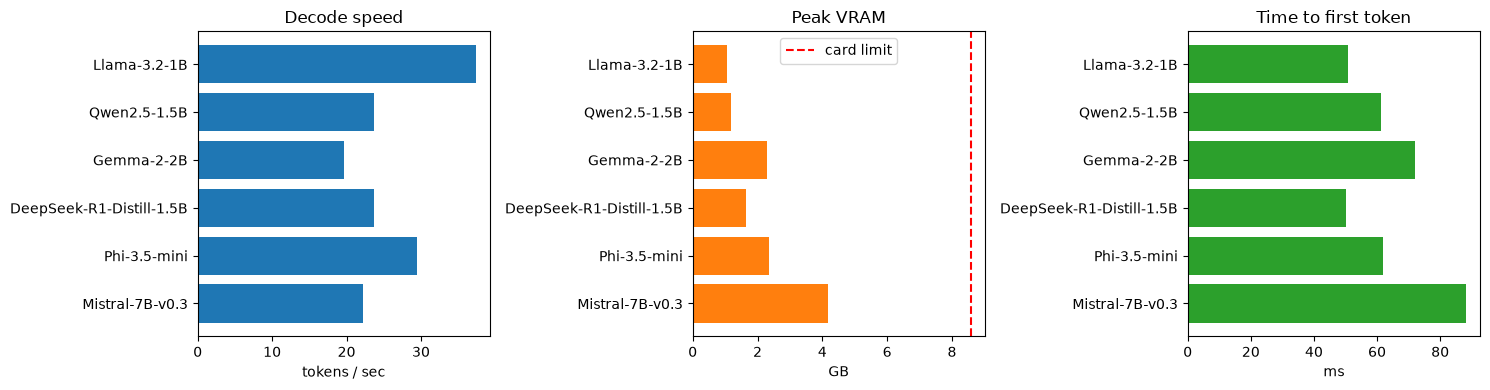

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = [r.model for r in results]

axes[0].barh(names, [r.decode_tok_per_s for r in results])
axes[0].set_xlabel("tokens / sec")
axes[0].set_title("Decode speed")

axes[1].barh(names, [r.peak_gb for r in results], color="tab:orange")
axes[1].axvline(TOTAL_VRAM_GB, ls="--", c="r", label="card limit")
axes[1].set_xlabel("GB")
axes[1].set_title("Peak VRAM")
axes[1].legend()

axes[2].barh(names, [r.ttft_ms for r in results], color="tab:green")
axes[2].set_xlabel("ms")
axes[2].set_title("Time to first token")

for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Limits of these numbers

Worth stating before anyone reads the table as authoritative.

- **Size is not controlled.** Mistral is roughly six times the Llama entry. Slower does not mean
  worse engineered.
- **Batch size 1.** Decode at batch 1 is bandwidth bound and leaves most of the card's compute
  idle. Throughput per GPU rises steeply with batching, so the cost column is pessimistic.
- **These numbers are specific to this card.** An RTX 3050 has lower memory bandwidth than a
  T4 despite being the newer architecture, and decode is bandwidth bound. Comparing tokens per
  second against someone running the same notebook on different hardware is meaningless.
- **Short prompts.** All five fit in a few hundred tokens, so the KV cache never grows large
  enough to dominate memory. Section 7 calculates what would happen at length rather than
  measuring it.
- **Advertised context is not usable context.** Several of these models degrade well before
  their stated limit, and nothing here tests that.
- **Five prompts is not an evaluation.** It is a smoke test that the models produce sensible
  text. No quality claim in this notebook is a benchmark result.